# LRT Market by Alignment Scenario — Main Corridor vs Full Length

Counts the potential LRT market for the **two alignment scenarios**
(`Input/lrt_alignment_flags.csv`, area flags supplied by the study team):

| Alignment | Line | Core areas | Transfer-influenced |
|---|---|---|---|
| **MainCorridor** | separate line Hamifrats ↔ Tirat Carmel | 13 areas (1–13) | Krayot + Haifa Airport + Nesher Lower (24–28) — reach the line with a **transfer** at the Hamifrats hub |
| **FullLength** | one line Nazareth ↔ Tirat Carmel | 20 areas (1–19, 23) | same five areas, same transfer logic |

Market tiers per alignment:

- **core** — both trip ends in core areas: one-seat ride;
- **influenced** — one end in a core area, the other in an influenced area:
  usable with a transfer, so capture there will be weaker (a transfer penalty in
  the capture model, not a reason to exclude the demand). Influenced↔influenced
  pairs never touch the line and are excluded;
- under MainCorridor, pairs touching the eastern areas (Hutzot…Nazareth) are
  **outside** the market entirely, per the flag table.

Counted on the four forecast all-modes matrices (BU/HS × 2040/2050) with the
2022 base for reference; the no-build transit trips inside each tier
(`nobuild_bus/rail`) are reported as the conversion base the LRT competes for.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 220)
SCEN = ['BU_2040', 'BU_2050', 'HS_2040', 'HS_2050']

def load_area(name):
    m = pd.read_csv(name, index_col=0)
    m.index = m.index.astype(int); m.columns = m.columns.astype(int)
    return m

flags = pd.read_csv('Input/lrt_alignment_flags.csv', index_col=0)
T22 = load_area('Output/transit/all_adjusted_area_2022.csv')
AREAS = list(T22.index)
assert list(flags.index) == AREAS
T_all = {'2022 base': T22, **{s: load_area(f'Output/forecast/all_modes_area_{s}.csv') for s in SCEN}}

bus22 = load_area('Output/bus/bus_od_area_new_filtered.csv').reindex(index=AREAS, columns=AREAS, fill_value=0)
rail22 = load_area('Output/train/train_od_area.csv').reindex(index=AREAS, columns=AREAS, fill_value=0) * 54.7 / 69.0
transit = {'2022 base': bus22 + rail22,
           **{s: load_area(f'Output/forecast/nobuild_bus_{s}.csv') + load_area(f'Output/forecast/nobuild_rail_{s}.csv')
              for s in SCEN}}

def tiers(core_col):
    c = flags[core_col].values.astype(bool)
    infl = flags.Influenced.values.astype(bool)
    core = np.outer(c, c)
    influenced = np.outer(c, infl) | np.outer(infl, c)
    return core, influenced

tier_mx = {}
for align in ['MainCorridor', 'FullLength']:
    core, infl = tiers(align)
    tier_mx[align] = (core, infl)
    pd.DataFrame(core.astype(int) * 2 + infl.astype(int), index=AREAS, columns=AREAS)\
      .to_csv(f'Output/forecast/lrt_market_tiers_{align}.csv')
print('tier matrices written (2 = core, 1 = influenced/transfer, 0 = outside)')

tier matrices written (2 = core, 1 = influenced/transfer, 0 = outside)


In [2]:
rows = []
for align in ['MainCorridor', 'FullLength']:
    core, infl = tier_mx[align]
    for s, T in T_all.items():
        tot = T.values.sum()
        rows.append({
            'alignment': align, 'scenario': s, 'total_trips': tot,
            'core_trips': T.values[core].sum(),
            'core_%': 100 * T.values[core].sum() / tot,
            'influenced_trips': T.values[infl].sum(),
            'influenced_%': 100 * T.values[infl].sum() / tot,
            'market_total': T.values[core | infl].sum(),
            'market_%': 100 * T.values[core | infl].sum() / tot,
            'transit_nobuild_core': transit[s].values[core].sum(),
            'transit_nobuild_influenced': transit[s].values[infl].sum(),
        })
summ = pd.DataFrame(rows)
summ.round(1).to_csv('Output/forecast/lrt_alignment_market_summary.csv', index=False)
print(summ.round(1).to_string(index=False))

   alignment  scenario  total_trips  core_trips  core_%  influenced_trips  influenced_%  market_total  market_%  transit_nobuild_core  transit_nobuild_influenced
MainCorridor 2022 base     276355.2     56566.3    20.5           16553.9           6.0       73120.2      26.5                6859.5                      4881.2
MainCorridor   BU_2040     380288.3     90589.0    23.8           18046.2           4.7      108635.1      28.6                7727.6                      5015.0
MainCorridor   BU_2050     459831.4    121398.8    26.4           19916.4           4.3      141315.2      30.7               11208.2                      5489.3
MainCorridor   HS_2040     384839.6     73152.3    19.0           17654.7           4.6       90807.0      23.6                7893.3                      4987.9
MainCorridor   HS_2050     461083.5     85398.6    18.5           20054.9           4.3      105453.5      22.9                9679.2                      5755.7
  FullLength 2022 base     2

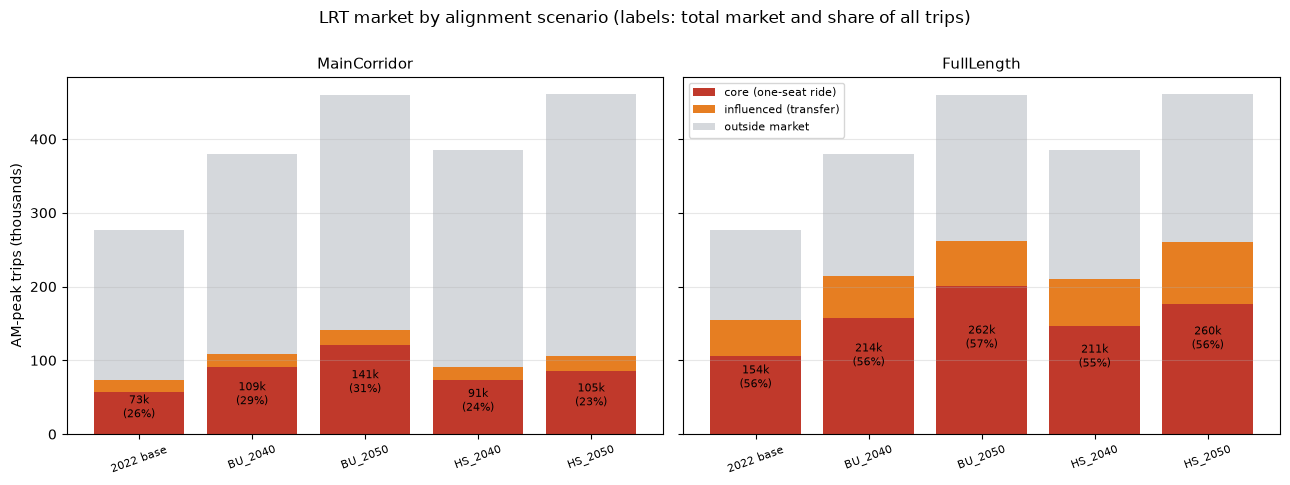

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
order = ['2022 base'] + SCEN
for ax, align in zip(axes, ['MainCorridor', 'FullLength']):
    d = summ[summ.alignment == align].set_index('scenario').reindex(order)
    x = np.arange(len(order))
    ax.bar(x, d.core_trips / 1000, color='#c0392b', label='core (one-seat ride)')
    ax.bar(x, d.influenced_trips / 1000, bottom=d.core_trips / 1000,
           color='#e67e22', label='influenced (transfer)')
    ax.bar(x, (d.total_trips - d.market_total) / 1000, bottom=d.market_total / 1000,
           color='#d5d8dc', label='outside market')
    for i, sc in enumerate(order):
        ax.text(i, d.market_total[sc] / 2000, f"{d.market_total[sc]/1000:.0f}k\n({d['market_%'][sc]:.0f}%)",
                ha='center', va='center', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(order, fontsize=8, rotation=20)
    ax.set_title(f'{align}', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('AM-peak trips (thousands)')
axes[1].legend(fontsize=8)
fig.suptitle('LRT market by alignment scenario (labels: total market and share of all trips)', y=1.0)
fig.tight_layout()
fig.savefig('Output/figures/lrt_alignment_markets.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# what FullLength adds over MainCorridor, and what MainCorridor loses to the transfer tier
piv = summ.pivot_table(index='scenario', columns='alignment',
                       values=['core_trips', 'market_total']).reindex(order)
piv[('delta', 'full_vs_main_core')] = piv[('core_trips', 'FullLength')] - piv[('core_trips', 'MainCorridor')]
piv[('delta', 'full_vs_main_market')] = piv[('market_total', 'FullLength')] - piv[('market_total', 'MainCorridor')]
print(piv.round(0).astype(int).to_string())

          core_trips              market_total                          delta                    
alignment FullLength MainCorridor   FullLength MainCorridor full_vs_main_core full_vs_main_market
scenario                                                                                         
2022 base     105999        56566       154423        73120             49433               81302
BU_2040       156910        90589       213868       108635             66321              105232
BU_2050       200446       121399       262430       141315             79048              121115
HS_2040       146042        73152       210745        90807             72890              119938
HS_2050       176751        85399       260060       105453             91353              154607


## Outputs

- `Output/forecast/lrt_market_tiers_{MainCorridor,FullLength}.csv` — 25×25 tier
  code per OD pair (2 = core, 1 = influenced/transfer, 0 = outside).
- `Output/forecast/lrt_alignment_market_summary.csv` — market counts per
  alignment × scenario-year (trips, shares, no-build transit conversion base).

The capture model runs per alignment: full capture rates on core pairs, a
transfer-penalized rate on influenced pairs (and, for MainCorridor, zero on the
eastern pairs the flags exclude).